# Newmark Simulation With Amplitude and Frequency Sweep

We solve the same 2-DOF internal-resonance system using Newmark-beta in second-order form:

$$
\mathbf{M}\,\ddot{\mathbf{u}} + \mathbf{C}\,\dot{\mathbf{u}} + \mathbf{f}_{\mathrm{int}}(\mathbf{u}) = \mathbf{f}_{\mathrm{ext}}(t; f_2, \Omega),
\qquad
\mathbf{u} = \begin{bmatrix}u_1 \\ u_2\end{bmatrix}.
$$

The model terms are

$$
\mathbf{M} = \mathbf{I}_2,
\qquad
\mathbf{C} = \begin{bmatrix}2\varepsilon\mu_1 & 0 \\ 0 & 2\varepsilon\mu_2\end{bmatrix},
$$

$$
\mathbf{f}_{\mathrm{int}}(\mathbf{u}) =
\begin{bmatrix}
\omega_1^2 u_1 - k_1 u_1 u_2 \\
\omega_2^2 u_2 - k_2 u_1^2
\end{bmatrix},
\qquad
\mathbf{K}_{\mathrm{tan}}(\mathbf{u}) = \frac{\partial \mathbf{f}_{\mathrm{int}}}{\partial \mathbf{u}} =
\begin{bmatrix}
\omega_1^2 - k_1 u_2 & -k_1 u_1 \\
-2k_2 u_1 & \omega_2^2
\end{bmatrix}.
$$

For each parameter pair $(f_2, \Omega)$, the external force is

$$
\mathbf{f}_{\mathrm{ext}}(t; f_2, \Omega) =
\begin{bmatrix}
\varepsilon f_1\cos(\Omega t) \\
\varepsilon^2 f_2\cos(\Omega t)
\end{bmatrix}.
$$

We sweep over:
- forcing amplitude $f_2 \in [f_{2,\min}, f_{2,\max}]$
- excitation frequency ratio $r = \Omega/\omega_2$ (hence $\Omega = r\,\omega_2$).

For each case, we compute steady-state RMS amplitudes after transient removal:

$$
A_i(f_2, \Omega) = \sqrt{\frac{1}{T_s}\int_{t_{\mathrm{trans}}}^{t_{\mathrm{end}}} u_i^2(t) \, dt},
\qquad i=1,2.
$$

In [5]:
import sys
import time
from pathlib import Path

import numpy as np
from numpy import pi
import matplotlib.pyplot as plt

project_root = Path.cwd()
while project_root.name != "Metamaterial beam" and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Modeling.models.newmark import newmark_beta_nonlinear

# Parameters (same system as previous notebook)
eps = 0.05
sigma2 = 0.0
freq_scale = 54 * 2 * pi
w1 = freq_scale
w2 = 2 * w1 - eps * sigma2
mu1, mu2 = 0.02 * freq_scale, 0.2 * freq_scale
k1, k2 = 400 * freq_scale**2, 400 * freq_scale**2
f1 = 0.0

# Sweep definitions
f2_values = np.linspace(0.0, 0.25, 10) / eps**2
freq_ratio_values = np.linspace(0.95, 1.05, 50)
omega_exc_values = freq_ratio_values * w2

# Time integration settings (kept moderate for 2D sweep runtime)
samples_per_period = 40
n_periods_total = 120
n_periods_transient = 80

beta = 0.25
gamma = 0.5
newton_tol = 1e-7
newton_maxiter = 20

def build_components(f2, omega_exc):
    M = np.eye(2)
    C = np.array([[2 * eps * mu1, 0.0], [0.0, 2 * eps * mu2]])

    def f_int(u):
        u1, u2 = u
        return np.array([
            w1**2 * u1 - k1 * u1 * u2,
            w2**2 * u2 - k2 * u1**2,
        ])

    def K_tan(u):
        u1, u2 = u
        return np.array([
            [w1**2 - k1 * u2, -k1 * u1],
            [-2 * k2 * u1, w2**2],
        ])

    def f_ext(t):
        return np.array([
            eps * f1 * np.cos(omega_exc * t),
            (eps**2) * f2 * np.cos(omega_exc * t),
        ])

    return M, C, f_int, K_tan, f_ext

def run_case_newmark(f2, omega_exc, u0=None, v0=None):
    dt = 2 * pi / (samples_per_period * omega_exc)
    t_end = n_periods_total * 2 * pi / omega_exc
    t_trans = n_periods_transient * 2 * pi / omega_exc

    n_steps = int(np.round(t_end / dt))
    t = np.linspace(0.0, n_steps * dt, n_steps + 1)

    M, C, f_int, K_tan, f_ext = build_components(f2, omega_exc)

    if u0 is None:
        u0 = np.array([0.0, 0.0])
    if v0 is None:
        v0 = np.array([1e-3, 0.0])

    a0_init = np.linalg.solve(M, f_ext(0.0) - C @ v0 - f_int(u0))

    t0 = time.perf_counter()
    u, v, a = newmark_beta_nonlinear(
        M=M, C=C, f_int=f_int, K_tan=K_tan, f_ext=f_ext,
        u0=u0, v0=v0, a0_init=a0_init,
        dt=dt, n_steps=n_steps,
        beta=beta, gamma=gamma,
        newton_tol=newton_tol, newton_maxiter=newton_maxiter,
    )
    runtime = time.perf_counter() - t0

    mask = t >= t_trans
    a1_rms = np.sqrt(np.mean(u[mask, 0] ** 2))
    a2_rms = np.sqrt(np.mean(u[mask, 1] ** 2))

    return {
        "t": t,
        "u": u,
        "v": v,
        "a": a,
        "a1_rms": a1_rms,
        "a2_rms": a2_rms,
        "runtime_s": runtime,
    }

# 2D sweep arrays: rows=freq ratio, cols=f2
A1 = np.zeros((len(freq_ratio_values), len(f2_values)))
A2 = np.zeros((len(freq_ratio_values), len(f2_values)))
RUNTIME = np.zeros((len(freq_ratio_values), len(f2_values)))

# Use continuation in each frequency row to accelerate convergence.
for i, omega_exc in enumerate(omega_exc_values):
    u0_row = np.array([0.0, 0.0])
    v0_row = np.array([1e-3, 0.0])

    for j, f2 in enumerate(f2_values):
        out = run_case_newmark(f2, omega_exc, u0=u0_row, v0=v0_row)
        A1[i, j] = out["a1_rms"]
        A2[i, j] = out["a2_rms"]
        RUNTIME[i, j] = out["runtime_s"]

        # Continuation initial conditions for next amplitude point.
        u0_row = out["u"][-1].copy()
        v0_row = out["v"][-1].copy()

print("Sweep completed.")
print(f"Grid size: {A1.shape[0]} frequency points x {A1.shape[1]} amplitude points")
print(f"Average runtime per case: {np.mean(RUNTIME):.3f} s")

Newmark Integration: 100%|██████████| 4800/4800 [00:00<00:00, 12303.92step/s]

Sweep completed.
Grid size: 50 frequency points x 10 amplitude points
Average runtime per case: 0.399 s


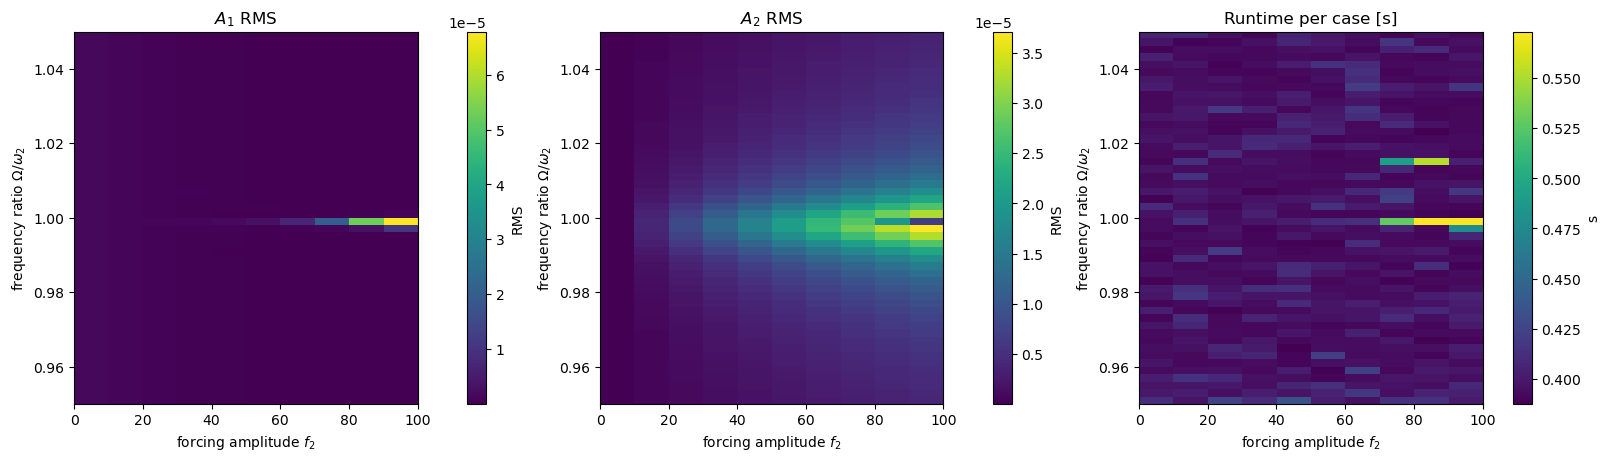

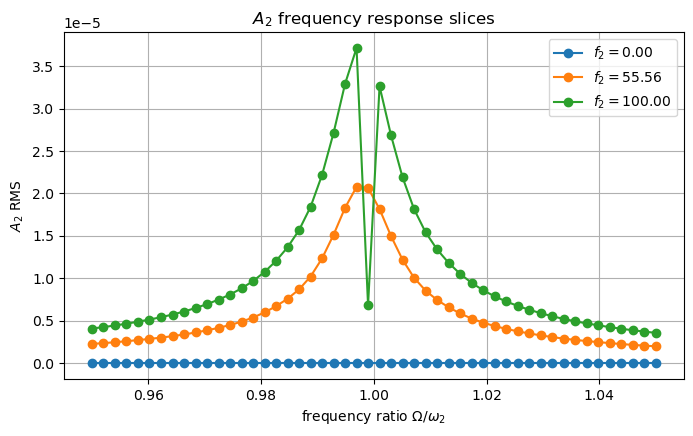

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

extent = [f2_values[0], f2_values[-1], freq_ratio_values[0], freq_ratio_values[-1]]

im0 = axs[0].imshow(A1, origin="lower", aspect="auto", extent=extent)
axs[0].set_title(r"$A_1$ RMS")
axs[0].set_xlabel(r"forcing amplitude $f_2$")
axs[0].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
fig.colorbar(im0, ax=axs[0], label="RMS")

im1 = axs[1].imshow(A2, origin="lower", aspect="auto", extent=extent)
axs[1].set_title(r"$A_2$ RMS")
axs[1].set_xlabel(r"forcing amplitude $f_2$")
axs[1].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
fig.colorbar(im1, ax=axs[1], label="RMS")

im2 = axs[2].imshow(RUNTIME, origin="lower", aspect="auto", extent=extent)
axs[2].set_title("Runtime per case [s]")
axs[2].set_xlabel(r"forcing amplitude $f_2$")
axs[2].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
fig.colorbar(im2, ax=axs[2], label="s")

plt.show()

# Frequency slices at selected amplitudes
pick_js = [0, len(f2_values)//2, len(f2_values)-1]
plt.figure(figsize=(8, 4.5))
for j in pick_js:
    plt.plot(freq_ratio_values, A2[:, j], marker="o", label=fr"$f_2={f2_values[j]:.2f}$")
plt.xlabel(r"frequency ratio $\Omega/\omega_2$")
plt.ylabel(r"$A_2$ RMS")
plt.title(r"$A_2$ frequency response slices")
plt.grid(True)
plt.legend()
plt.show()